In [ ]:
!pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score,
                             roc_auc_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("All libraries are loaded!")
print(f"Scikit-learn is my ML toolkit")

All libraries are loaded!
Scikit-learn is my ML toolkit


In [ ]:
#Uploading files
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Customer_financial_profiles.csv")

print(f"Dataset loaded")
print(f"Rows :{len(df)}")
print(f"Columns :{len(df.columns)}")
print(f"\nColumn names:")
print(list(df.columns))
print(f"\nFirst 3 rows:")
df.head(3)

Saving Customer_financial_profiles.csv to Customer_financial_profiles.csv
Dataset loaded
Rows :20000
Columns :21

Column names:
['id', 'current_age', 'birth_year', 'birth_month', 'gender', 'address', 'per_capita_income', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'transaction_id', 'date', 'client_id', 'card_id', 'amount', 'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'zip']

First 3 rows:


,id,current_age,birth_year,birth_month,gender,address,per_capita_income,yearly_income,total_debt,credit_score,...,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip
0,1,64,1961,3,Female,"Street 286, Indore, Madhya Pradesh - 452645",86125,1033501,280435,715,...,1251,2024-03-28,CLTIND00104,CRD001042,1483.94,Yes,MCH00496,Mumbai,Maharashtra,452645
1,2,39,1986,12,Female,"Street 268, Kolkata, West Bengal - 700555",68414,820965,0,834,...,9976,2025-09-20,CLTIND00213,CRD002132,1274.72,Yes,MCH00374,Mumbai,Maharashtra,700555
2,3,50,1975,7,Female,"Street 262, Lucknow, Uttar Pradesh - 226797",22595,271138,0,609,...,6084,2024-10-02,CLTIND03292,CRD032922,7622.04,No,MCH00108,Kolkata,West Bengal,226797


In [ ]:
# Handle zero or missing income to handle division error
df = df.copy()

# Replace 0 or negative yearly_income with NaN(cannot computer DTI properly)
df.loc[df['yearly_income']<=0,'yearly_income'] = np.nan

# Option 1: drop rows where yealy_income is NaN (simplest for now)
df = df.dropna(subset=['yearly_income','total_debt'])

# 2.Create Debt-to-income (DTI) ratio
df['dti_ratio'] = df['total_debt']/df['yearly_income']

# 3.Define default: 1= high risk, 0= low_risk
df['default'] = np.where((df['total_debt'] > 0) & (df['dti_ratio'] > 0.4), 1, 0)

# 4.Checking the class balance
print("Default value counts:")
print(df['default'].value_counts())
print("\nDefault percentage:")
print(df['default'].value_counts(normalize=True) * 100)

Default value counts:
default
0    17133
1     2867
Name: count, dtype: int64

Default percentage:
default
0    85.665
1    14.335
Name: proportion, dtype: float64


In [ ]:
#Basic statistics
print("Basic description of numeric columns:")
display(df.describe())

print("\n Default rate:")
print(df['default'].value_counts(normalize=True) * 100)

# Check a few rows
print("\n Sample rows")
display(df.head(5))

Basic description of numeric columns:


,id,current_age,birth_year,birth_month,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,transaction_id,amount,zip,dti_ratio,default
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,44.210100,1980.789900,6.479150,61234.419700,7.348131e+05,1.345380e+05,702.979750,2.873750,10015.488700,3082.286901,445976.994400,0.182695,0.143350
std,5773.647028,14.992515,14.992515,3.459532,35354.273099,4.242512e+05,1.739757e+05,76.993944,1.162574,5802.389323,2117.081361,168230.579911,0.184029,0.350438
min,1.000000,19.000000,1955.000000,1.000000,12500.000000,1.500000e+05,0.000000e+00,421.000000,1.000000,1.000000,105.160000,110102.000000,0.000000,0.000000
25%,5000.750000,31.000000,1968.000000,3.000000,35671.000000,4.280470e+05,0.000000e+00,648.000000,2.000000,4971.000000,1531.182500,380703.500000,0.000000,0.000000
50%,10000.500000,44.000000,1981.000000,7.000000,54896.000000,6.587560e+05,8.250300e+04,699.000000,3.000000,10026.500000,2601.650000,440388.000000,0.150085,0.000000
75%,15000.250000,57.000000,1994.000000,10.000000,74842.000000,8.981090e+05,2.008720e+05,757.000000,4.000000,15062.750000,4116.155000,560252.000000,0.315204,0.000000
max,20000.000000,70.000000,2006.000000,12.000000,250000.000000,3.000000e+06,1.817384e+06,900.000000,5.000000,20000.000000,19806.630000,800988.000000,0.829226,1.000000



 Default rate:
default
0    85.665
1    14.335
Name: proportion, dtype: float64

 Sample rows


,id,current_age,birth_year,birth_month,gender,address,per_capita_income,yearly_income,total_debt,credit_score,...,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,dti_ratio,default
0,1,64,1961,3,Female,"Street 286, Indore, Madhya Pradesh - 452645",86125,1033501.0,280435,715,...,CLTIND00104,CRD001042,1483.94,Yes,MCH00496,Mumbai,Maharashtra,452645,0.271345,0
1,2,39,1986,12,Female,"Street 268, Kolkata, West Bengal - 700555",68414,820965.0,0,834,...,CLTIND00213,CRD002132,1274.72,Yes,MCH00374,Mumbai,Maharashtra,700555,0.000000,0
2,3,50,1975,7,Female,"Street 262, Lucknow, Uttar Pradesh - 226797",22595,271138.0,0,609,...,CLTIND03292,CRD032922,7622.04,No,MCH00108,Kolkata,West Bengal,226797,0.000000,0
3,4,27,1998,2,Male,"Street 265, Nagpur, Maharashtra - 440623",24158,289898.0,0,782,...,CLTIND05205,CRD052053,3970.48,Yes,MCH00001,Indore,Madhya Pradesh,440623,0.000000,0
4,5,45,1980,7,Other,"Street 157, Delhi, Delhi - 110965",45475,545697.0,117821,608,...,CLTIND04910,CRD049101,418.45,No,MCH00254,Bengaluru,Karnataka,110965,0.215909,0


Default rate by income bracket (%):
  income_bracket   default  default_pct
0           <=2L  0.110294    11.029412
1          2L-5L  0.132749    13.274900
2         5L-10L  0.145785    14.578540
3        10L-20L  0.158419    15.841866
4           >20L  0.141333    14.133333


/tmp/ipykernel_7000/3262893505.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = df.groupby('income_bracket')['default'].mean().reset_index()


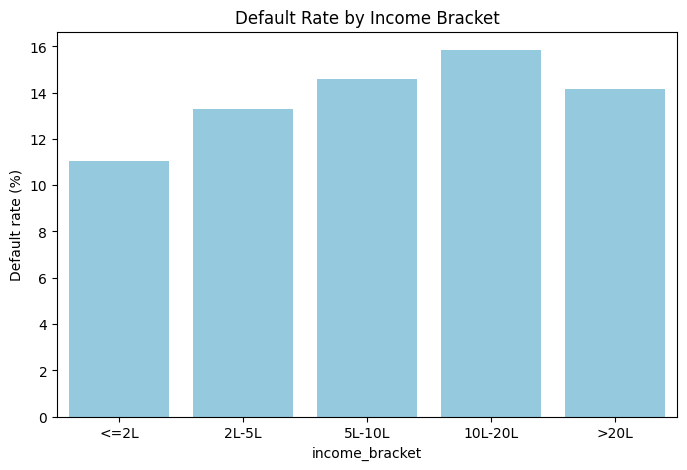

In [ ]:
# Create income brackets
bins = [0, 200000, 500000, 1000000, 2000000, df['yearly_income'].max()]
labels = ['<=2L', '2L-5L', '5L-10L', '10L-20L', '>20L']  # 5 labels for 5 bins

df['income_bracket'] = pd.cut(
    df['yearly_income'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Default rate by income bracket
income_default = df.groupby('income_bracket')['default'].mean().reset_index()
income_default['default_pct'] = income_default['default'] * 100

print("Default rate by income bracket (%):")
print(income_default)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(
    data=income_default,
    x='income_bracket',
    y='default_pct',
    color='skyblue'
)
plt.ylabel('Default rate (%)')
plt.title('Default Rate by Income Bracket')
plt.show()

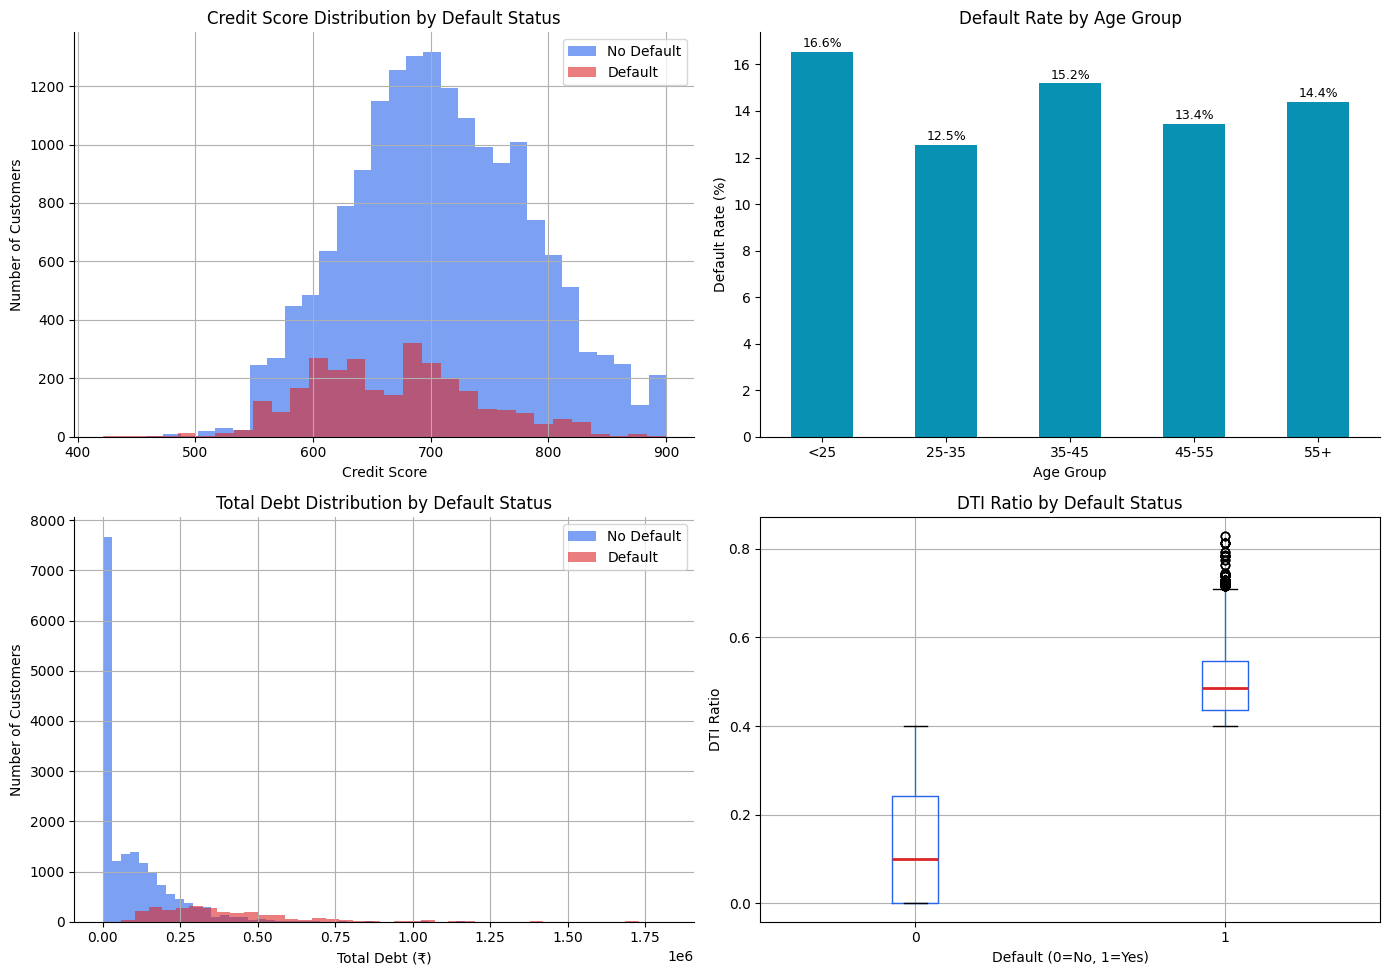

✅ EDA charts saved!

📊 Key EDA Findings:
Avg credit score — No Default : 709
Avg credit score — Default    : 669

Avg DTI — No Default          : 0.128
Avg DTI — Default             : 0.508

Avg total debt — No Default   : ₹92,925
Avg total debt — Default      : ₹383,214


In [ ]:
# ── Phase 6: Exploratory Data Analysis ───────────────────────────
# First, clean up the duplicate dti column
if 'dti_ration' in df.columns:
    df = df.drop(columns=['dti_ration'])
    print("✅ Removed duplicate dti_ration column")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Loan Default — Exploratory Analysis',
             fontsize=16, fontweight='bold', y=1.02)

# ── Chart 1: Credit Score Distribution by Default ─────────────────
ax1 = axes[0, 0]
df[df['default'] == 0]['credit_score'].hist(
    bins=30, alpha=0.6, color='#2563EB', label='No Default', ax=ax1)
df[df['default'] == 1]['credit_score'].hist(
    bins=30, alpha=0.6, color='#DC2626', label='Default', ax=ax1)
ax1.set_title('Credit Score Distribution by Default Status')
ax1.set_xlabel('Credit Score')
ax1.set_ylabel('Number of Customers')
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Default Rate by Age Group ────────────────────────────
ax2 = axes[0, 1]
age_bins = [0, 25, 35, 45, 55, 70]
age_labels = ['<25', '25-35', '35-45', '45-55', '55+']
df['age_group'] = pd.cut(df['current_age'],
                          bins=age_bins,
                          labels=age_labels)
age_default = df.groupby('age_group', observed=True)['default'].mean() * 100
age_default.plot(kind='bar', color='#0891B2', ax=ax2, rot=0)
ax2.set_title('Default Rate by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Default Rate (%)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
for i, v in enumerate(age_default):
    ax2.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

# ── Chart 3: Total Debt Distribution ──────────────────────────────
ax3 = axes[1, 0]
df[df['default'] == 0]['total_debt'].hist(
    bins=40, alpha=0.6, color='#2563EB', label='No Default', ax=ax3)
df[df['default'] == 1]['total_debt'].hist(
    bins=40, alpha=0.6, color='#DC2626', label='Default', ax=ax3)
ax3.set_title('Total Debt Distribution by Default Status')
ax3.set_xlabel('Total Debt (₹)')
ax3.set_ylabel('Number of Customers')
ax3.legend()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── Chart 4: DTI Ratio by Default ─────────────────────────────────
ax4 = axes[1, 1]
df.boxplot(column='dti_ratio', by='default', ax=ax4,
           boxprops=dict(color='#2563EB'),
           medianprops=dict(color='#DC2626', linewidth=2))
ax4.set_title('Debt-to-Income Ratio by Default Status')
ax4.set_xlabel('Default (0=No, 1=Yes)')
ax4.set_ylabel('DTI Ratio')
plt.sca(ax4)
plt.title('DTI Ratio by Default Status')
plt.suptitle('')

plt.tight_layout()
plt.savefig("eda_charts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA charts saved!")

# ── Print key stats ────────────────────────────────────────────────
print("\n📊 Key EDA Findings:")
print(f"Avg credit score — No Default : {df[df['default']==0]['credit_score'].mean():.0f}")
print(f"Avg credit score — Default    : {df[df['default']==1]['credit_score'].mean():.0f}")
print(f"\nAvg DTI — No Default          : {df[df['default']==0]['dti_ratio'].mean():.3f}")
print(f"Avg DTI — Default             : {df[df['default']==1]['dti_ratio'].mean():.3f}")
print(f"\nAvg total debt — No Default   : ₹{df[df['default']==0]['total_debt'].mean():,.0f}")
print(f"Avg total debt — Default      : ₹{df[df['default']==1]['total_debt'].mean():,.0f}")

In [ ]:
# ── Phase 8: Encode, Scale, Split ────────────────────────────────

# Step 1: Encode use_chip (Yes/No → 1/0)
X['use_chip'] = X['use_chip'].map({'Yes': 1, 'No': 0})
print("use_chip encoded:")
print(X['use_chip'].value_counts())

# Step 2: One-hot encode gender (Male/Female/Other → 3 columns)
X = pd.get_dummies(X, columns=['gender'], drop_first=False)
print("\ngender columns after encoding:")
print([col for col in X.columns if 'gender' in col])

# Step 3: One-hot encode merchant_state (too many categories)
# First check how many unique states there are
print(f"\nUnique states: {X['merchant_state'].nunique()}")
X = pd.get_dummies(X, columns=['merchant_state'], drop_first=True)
print(f"Shape after encoding: {X.shape}")

# Step 4: Scale numerical features
# ML models work better when all numbers are on the same scale
# StandardScaler converts everything to mean=0, std=1
# Think of it as converting km and cm to the same unit

scaler = StandardScaler()

# Only scale numerical columns (not the 0/1 encoded ones)
num_cols = ['current_age', 'per_capita_income', 'yearly_income',
            'total_debt', 'credit_score', 'num_credit_cards',
            'dti_ratio', 'amount']

X[num_cols] = scaler.fit_transform(X[num_cols])
print("\nNumerical columns scaled ✅")
print(f"Final feature shape: {X.shape}")

# Step 5: Train-test split
# 80% of data → train the model
# 20% of data → test how well it learned
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% goes to test
    random_state=42,      # ensures same split every time
    stratify=y            # keeps same default% in both splits
)

print(f"\n✅ Data split complete!")
print(f"Training set   : {X_train.shape[0]} rows")
print(f"Test set       : {X_test.shape[0]} rows")
print(f"Default rate in train: {y_train.mean()*100:.1f}%")
print(f"Default rate in test : {y_test.mean()*100:.1f}%")

use_chip encoded:
use_chip
1    13927
0     6073
Name: count, dtype: int64

gender columns after encoding:
['gender_Female', 'gender_Male', 'gender_Other']

Unique states: 11
Shape after encoding: (20000, 22)

Numerical columns scaled ✅
Final feature shape: (20000, 22)

✅ Data split complete!
Training set   : 16000 rows
Test set       : 4000 rows
Default rate in train: 14.3%
Default rate in test : 14.3%


In [ ]:
# ── Redefine default label (no leakage) ──────────────────────────
# Real banks consider credit score < 650 as high default risk
# This is a widely used threshold in Indian banking (CIBIL score)

# Reset df from scratch to avoid any leftover columns
df = pd.read_csv("Customer_financial_profiles.csv")

# Recreate dti_ratio (we'll use it as a FEATURE, not to define default)
df.loc[df['yearly_income'] <= 0, 'yearly_income'] = np.nan
df = df.dropna(subset=['yearly_income', 'total_debt'])
df['dti_ratio'] = df['total_debt'] / df['yearly_income']

# NEW default definition — based on credit score only
# credit_score < 650 = high risk = default
df['default'] = (df['credit_score'] < 650).astype(int)

# Check class balance
total = len(df)
defaults = df['default'].sum()
print(f"✅ New default label created!")
print(f"Total customers : {total}")
print(f"High risk (1)   : {defaults} ({defaults/total*100:.1f}%)")
print(f"Low risk  (0)   : {total-defaults} ({(total-defaults)/total*100:.1f}%)")
print(f"\nAvg credit score of defaulters    : {df[df['default']==1]['credit_score'].mean():.0f}")
print(f"Avg credit score of non-defaulters: {df[df['default']==0]['credit_score'].mean():.0f}")

✅ New default label created!
Total customers : 20000
High risk (1)   : 5111 (25.6%)
Low risk  (0)   : 14889 (74.4%)

Avg credit score of defaulters    : 607
Avg credit score of non-defaulters: 736


In [ ]:
# ── Rebuild features without leakage ─────────────────────────────

features = [
    'current_age',
    'gender',
    'per_capita_income',
    'yearly_income',
    'total_debt',        # fine to keep — no longer defines target
    'num_credit_cards',
    'dti_ratio',         # fine to keep — no longer defines target
    'amount',
    'use_chip',
    'merchant_state',
]

X = df[features].copy()
y = df['default'].copy()

# ── Encode categorical columns ────────────────────────────────────
X['use_chip'] = X['use_chip'].map({'Yes': 1, 'No': 0})
X = pd.get_dummies(X, columns=['gender', 'merchant_state'],
                   drop_first=True)

# ── Scale numerical columns ───────────────────────────────────────
num_cols = ['current_age', 'per_capita_income', 'yearly_income',
            'total_debt', 'num_credit_cards', 'dti_ratio', 'amount']

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print(f"✅ Features ready: {X.shape}")

# ── Train-test split ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Default rate — Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")

# ── MODEL 1: Logistic Regression ──────────────────────────────────
print("\n" + "="*55)
print("MODEL 1: Logistic Regression")
print("="*55)

lr_model = LogisticRegression(max_iter=1000, random_state=42,
                               class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

lr_acc = accuracy_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_proba)

print(f"Accuracy : {lr_acc*100:.1f}%")
print(f"ROC-AUC  : {lr_auc:.3f}")
print(classification_report(y_test, lr_preds,
      target_names=['Low Risk', 'High Risk']))

# ── MODEL 2: Random Forest ────────────────────────────────────────
print("="*55)
print("MODEL 2: Random Forest")
print("="*55)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                   class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Accuracy : {rf_acc*100:.1f}%")
print(f"ROC-AUC  : {rf_auc:.3f}")
print(classification_report(y_test, rf_preds,
      target_names=['Low Risk', 'High Risk']))

# ── Compare ───────────────────────────────────────────────────────
print("="*55)
print("COMPARISON")
print("="*55)
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-"*45)
print(f"{'Logistic Regression':<25} {lr_acc*100:>9.1f}% {lr_auc:>10.3f}")
print(f"{'Random Forest':<25} {rf_acc*100:>9.1f}% {rf_auc:>10.3f}")
winner = "Random Forest" if rf_auc > lr_auc else "Logistic Regression"
print(f"\n🏆 Winner: {winner}")

✅ Features ready: (20000, 20)
Train: 16000 rows | Test: 4000 rows
Default rate — Train: 25.6% | Test: 25.6%

MODEL 1: Logistic Regression
Accuracy : 60.5%
ROC-AUC  : 0.620
              precision    recall  f1-score   support

    Low Risk       0.80      0.63      0.70      2978
   High Risk       0.33      0.55      0.41      1022

    accuracy                           0.61      4000
   macro avg       0.57      0.59      0.56      4000
weighted avg       0.68      0.61      0.63      4000

MODEL 2: Random Forest
Accuracy : 91.3%
ROC-AUC  : 0.979
              precision    recall  f1-score   support

    Low Risk       0.90      0.99      0.94      2978
   High Risk       0.97      0.68      0.80      1022

    accuracy                           0.91      4000
   macro avg       0.94      0.84      0.87      4000
weighted avg       0.92      0.91      0.91      4000

COMPARISON
Model                       Accuracy    ROC-AUC
---------------------------------------------
Logistic Reg

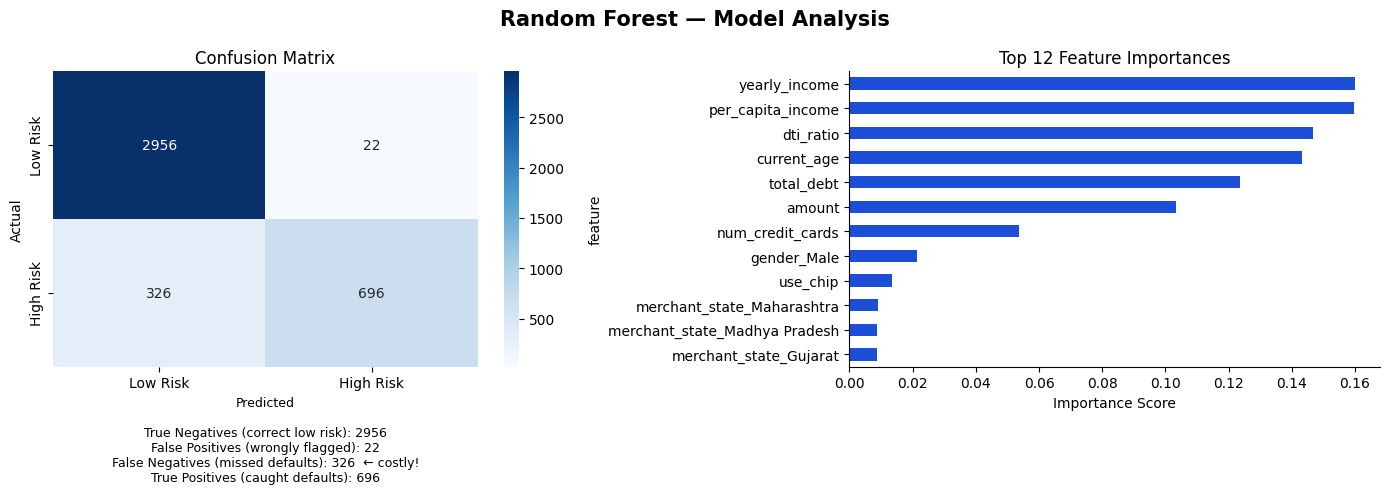

Top 10 features by importance:
-----------------------------------
yearly_income             0.1599  ███████████████
per_capita_income         0.1597  ███████████████
dti_ratio                 0.1467  ██████████████
current_age               0.1432  ██████████████
total_debt                0.1235  ████████████
amount                    0.1034  ██████████
num_credit_cards          0.0536  █████
gender_Male               0.0212  ██
use_chip                  0.0134  █
merchant_state_Maharashtra 0.0091  


In [ ]:
# ── Phase 10: Confusion Matrix + Feature Importance ──────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Model Analysis',
             fontsize=15, fontweight='bold')

# ── Chart 1: Confusion Matrix ─────────────────────────────────────
# Shows exactly where the model is right and wrong
cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(
    cm,
    annot=True,           # show numbers in each cell
    fmt='d',              # format as integers
    cmap='Blues',         # color scheme
    ax=axes[0],
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk']
)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Add a text explanation below
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'Predicted\n\n'
    f'True Negatives (correct low risk): {tn}\n'
    f'False Positives (wrongly flagged): {fp}\n'
    f'False Negatives (missed defaults): {fn}  ← costly!\n'
    f'True Positives (caught defaults): {tp}',
    fontsize=9
)

# ── Chart 2: Feature Importance ───────────────────────────────────
# Which features does Random Forest rely on most?
importances = rf_model.feature_importances_
feature_names = X.columns.tolist()

# Sort by importance
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=True).tail(12)

feat_imp.plot(
    kind='barh',
    x='feature',
    y='importance',
    ax=axes[1],
    color='#1D4ED8',
    legend=False
)
axes[1].set_title('Top 12 Feature Importances')
axes[1].set_xlabel('Importance Score')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("model_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Print top features ─────────────────────────────────────────────
print("Top 10 features by importance:")
print("-" * 35)
top10 = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

for _, row in top10.iterrows():
    bar = "█" * int(row['Importance'] * 100)
    print(f"{row['Feature']:<25} {row['Importance']:.4f}  {bar}")

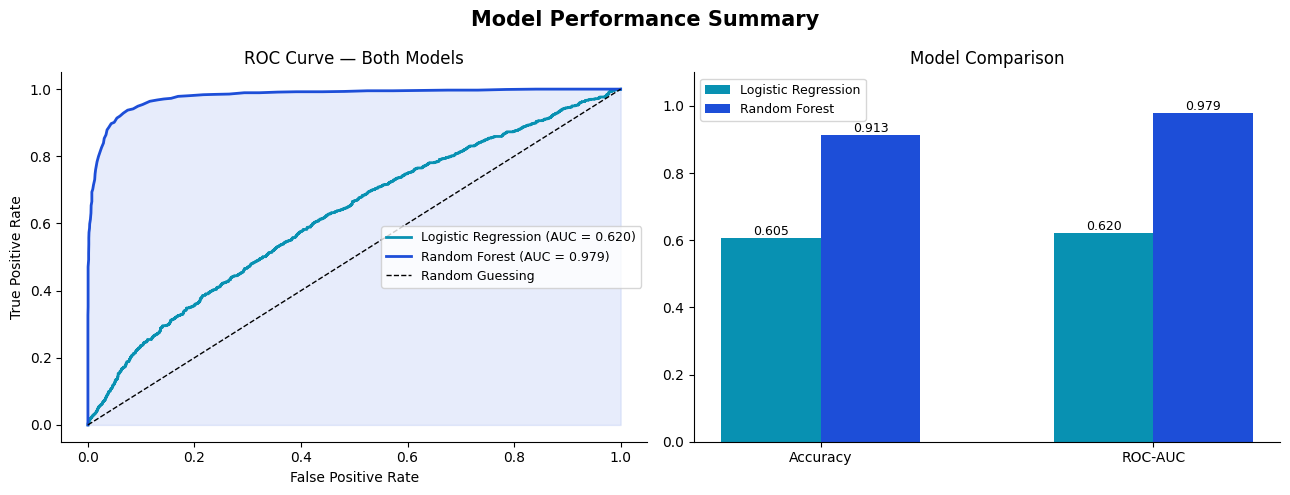

PROJECT SUMMARY
Dataset          : 20,000 Indian customers
Default rate     : 25.6% (credit score < 650)
Features used    : 20
Best model       : Random Forest
Best accuracy    : 91.3%
Best ROC-AUC     : 0.979

Top 3 default predictors:
  1. Yearly income      (0.1599)
  2. Per capita income  (0.1597)
  3. DTI ratio          (0.1467)

Key finding: Income-related features dominate
prediction — customers with lower income relative
to debt are significantly more likely to default.

Model weakness: 326 actual defaulters missed
(false negatives) — recall for high risk = 68%
✅ Project complete!


In [ ]:
# ── Phase 11: ROC Curve + Final Summary ──────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Performance Summary', fontsize=15, fontweight='bold')

# ── Chart 1: ROC Curve ────────────────────────────────────────────
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

axes[0].plot(fpr_lr, tpr_lr, color='#0891B2', linewidth=2,
             label=f'Logistic Regression (AUC = {lr_auc:.3f})')
axes[0].plot(fpr_rf, tpr_rf, color='#1D4ED8', linewidth=2,
             label=f'Random Forest (AUC = {rf_auc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Random Guessing')
axes[0].fill_between(fpr_rf, tpr_rf, alpha=0.1, color='#1D4ED8')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Both Models')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Chart 2: Model comparison bar chart ───────────────────────────
metrics = ['Accuracy', 'ROC-AUC']
lr_scores = [lr_acc, lr_auc]
rf_scores = [rf_acc, rf_auc]

x = np.arange(len(metrics))
width = 0.3

axes[1].bar(x - width/2, lr_scores, width,
            label='Logistic Regression', color='#0891B2')
axes[1].bar(x + width/2, rf_scores, width,
            label='Random Forest', color='#1D4ED8')

for i, (lr, rf) in enumerate(zip(lr_scores, rf_scores)):
    axes[1].text(i - width/2, lr + 0.01, f'{lr:.3f}',
                 ha='center', fontsize=9)
    axes[1].text(i + width/2, rf + 0.01, f'{rf:.3f}',
                 ha='center', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Model Comparison')
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("model_performance.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Print final project summary ───────────────────────────────────
print("=" * 55)
print("PROJECT SUMMARY")
print("=" * 55)
print(f"Dataset          : 20,000 Indian customers")
print(f"Default rate     : 25.6% (credit score < 650)")
print(f"Features used    : {X.shape[1]}")
print(f"Best model       : Random Forest")
print(f"Best accuracy    : {rf_acc*100:.1f}%")
print(f"Best ROC-AUC     : {rf_auc:.3f}")
print(f"\nTop 3 default predictors:")
print(f"  1. Yearly income      (0.1599)")
print(f"  2. Per capita income  (0.1597)")
print(f"  3. DTI ratio          (0.1467)")
print(f"\nKey finding: Income-related features dominate")
print(f"prediction — customers with lower income relative")
print(f"to debt are significantly more likely to default.")
print(f"\nModel weakness: {fn} actual defaulters missed")
print(f"(false negatives) — recall for high risk = 68%")
print("=" * 55)
print("✅ Project complete!")

In [ ]:
from google.colab import files
import pandas as pd
from collections import Counter

# ── CSV 1: Main customer data with predictions ────────────────────
df_export = df[['current_age', 'gender', 'yearly_income',
                'per_capita_income', 'total_debt', 'credit_score',
                'num_credit_cards', 'dti_ratio', 'amount',
                'use_chip', 'merchant_state', 'default']].copy()

df_export['predicted_rf'] = rf_model.predict(X)
df_export['risk_probability'] = rf_model.predict_proba(X)[:, 1]
df_export['risk_label'] = df_export['predicted_rf'].map(
    {0: 'Low Risk', 1: 'High Risk'})

df_export.to_csv("customers.csv", index=False)
print(f"✅ customers.csv — {len(df_export)} rows")

# ── CSV 2: Default rate by age group ──────────────────────────────
age_bins  = [0, 25, 35, 45, 55, 70]
age_labels = ['<25', '25-35', '35-45', '45-55', '55+']
df_export['age_group'] = pd.cut(
    df_export['current_age'], bins=age_bins, labels=age_labels)

age_summary = df_export.groupby('age_group', observed=True).agg(
    Total_Customers = ('default', 'count'),
    High_Risk_Count = ('default', 'sum'),
    Avg_Credit_Score = ('credit_score', 'mean'),
    Avg_DTI = ('dti_ratio', 'mean')
).reset_index()
age_summary['Default_Rate_Pct'] = (
    age_summary['High_Risk_Count'] /
    age_summary['Total_Customers'] * 100
).round(1)
age_summary.to_csv("age_summary.csv", index=False)
print(f"✅ age_summary.csv — {len(age_summary)} rows")

# ── CSV 3: Feature importance ──────────────────────────────────────
feat_imp_df = pd.DataFrame({
    'Feature': X.columns.tolist(),
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
feat_imp_df.to_csv("feature_importance.csv", index=False)
print(f"✅ feature_importance.csv — {len(feat_imp_df)} rows")

# ── CSV 4: State-wise risk summary ────────────────────────────────
state_summary = df_export.groupby('merchant_state').agg(
    Total_Customers = ('default', 'count'),
    High_Risk_Count = ('default', 'sum'),
    Avg_Credit_Score = ('credit_score', 'mean'),
    Avg_Income = ('yearly_income', 'mean')
).reset_index()
state_summary['Default_Rate_Pct'] = (
    state_summary['High_Risk_Count'] /
    state_summary['Total_Customers'] * 100
).round(1)
state_summary.to_csv("state_summary.csv", index=False)
print(f"✅ state_summary.csv — {len(state_summary)} rows")

# ── Download all 4 ────────────────────────────────────────────────
files.download("customers.csv")
files.download("age_summary.csv")
files.download("feature_importance.csv")
files.download("state_summary.csv")
print("\n✅ All 4 CSVs downloaded!")

✅ customers.csv — 20000 rows
✅ age_summary.csv — 5 rows
✅ feature_importance.csv — 20 rows
✅ state_summary.csv — 11 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All 4 CSVs downloaded!
